# Prototype: Run outbreak dynamics model

A prototype test of the consolidated outbreak dynamics model

In [1]:

import os
import importlib
from copy import deepcopy
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

import inframind_proteus.outbreak_dynamics
from inframind_proteus.outbreak_dynamics.sampling import sample_lhs, NormalPrior, GammaPrior

importlib.reload(inframind_proteus.outbreak_dynamics)
from inframind_proteus.outbreak_dynamics import (
    SimulationConfig, RenewalSimulator, SimulationOutput,
    LogisticRT, ConstantGammaGT, build_calibration_params_df,
    build_initial_infec_df
)

from inframind_proteus.outbreak_dynamics.utils import (
    load_yaml_dict, epiweek_to_date
)


## Run simulations for one location and season

In [2]:
# =================
# SPECIFIC PARAMETERS

uf = "SE" #  "SE" # "PI" # "SP"
year = 2023
epiweeek_sim_start = 26   # Train data ends at epiweek 25
epiweek_sim_end = 45

num_simulations = int(2**20)

# =================

# --- General UF-level demographic data
uf_table_df = pd.read_csv(Path("../../data/demographic/uf_table.csv"))
population_size = uf_table_df.set_index("uf").loc[uf, f"population_{year}"].item()  # Take the population at the start of the season for reference.


# --- Observation data
observations_sr = (
    pd.read_csv(
        f"../../data/disease/dengue_cases_uf_weekly/dengue_{uf}.csv",
        parse_dates=["date"],
    )
    .set_index("date")["value"]
)


# --- Simulation setup
config_dict = load_yaml_dict(Path("../../configs/prototype_run_dynamic_model.yaml"))
# config_dict = load_yaml_dict(Path("../../configs/outbreak_dynamics_example.yaml"))
simulator = RenewalSimulator.from_config_dict(config_dict)

# Override desired configurations
config = simulator.config
config.mode = "calibration"
config.num_simulations = num_simulations
config.location.population_size = population_size

# config.scoring.metrics = ["wis", "nb_loglikelihood"]

# Simulation and calibration time ranges
config.temporal.sim_start = _sim_start = epiweek_to_date(100 * year + epiweeek_sim_start)
_sim_end = epiweek_to_date(100 * (year + 1) + epiweek_sim_end)
config.num_time_steps = int(np.ceil((_sim_end - _sim_start).days / 7))
config.temporal.calibration_start = epiweek_to_date(100 * year + 41)  # Mosqlimate instructions
config.temporal.calibration_end = epiweek_to_date(100 * (year + 1) + 40)  # Mosqlimate instructions
config.temporal.zero_date = config.temporal.calibration_start

# === Pre-sampling prototype: SET SCALING TO MATCH PRE-SIMULATION MEAN/STD
# --- Fetch incidence at pre-simulation phase
# presim_start_date = config.temporal.sim_start - pd.Timedelta(simulator._gt_max_steps, unit="W")
presim_start_date = config.temporal.sim_start - pd.Timedelta(4, unit="W")
presim_end_date = config.temporal.sim_start - pd.Timedelta(1, unit="W")

# Observation series at the pre-sampling window
presamp_obs_sr = observations_sr.loc[presim_start_date:presim_end_date]

# Define scaling prior based on pre-simulation phase incidence
_mean_cases, _std_cases = presamp_obs_sr.mean(), presamp_obs_sr.std()

# Calculate the relative scaling factor to
# OBS: Could directly calculate the scaling factor, but it's less interpretable and harder to bound.
# Assumes initialization with method "ones" (infections = 1)
_coef = config.observation_model.reference_population_size / population_size / 1.
_mean_rel_scaling = _mean_cases * _coef
_std_rel_scaling = _std_cases * _coef

# Define the prior
config.sampling.param_priors["notif_relative_scale"] = GammaPrior(_mean_rel_scaling, _std_rel_scaling)
# config.sampling.param_priors["notif_relative_scale"] = GammaPrior(_mean_rel_scaling, 0.1 * _std_rel_scaling)  # TEST: Reduce variance, since it should mostly come from stochasticity in the end
# ====


# --- Build auxiliary data frames for simulations
params_df = build_calibration_params_df(config.num_simulations, config.sampling)
config.num_simulations = num_simulations = params_df.shape[0]  # Update in case sampling method changes number of simulations
# params_df.index.name = "i_simulation"
initial_infec_df = build_initial_infec_df(
    config.num_simulations, simulator._gt_max_steps, config.temporal.step_dt,
    config.initial_infections
)

# --- Run simulations (calibration mode)
print(f"Running {config.num_simulations} simulations...")
# results = simulator.run(
results = simulator.run_sequential_chunks(
    params_df=params_df,
    initial_infec_df=initial_infec_df,
    observations_sr=observations_sr,
)
print("done!")

Running 1048576 simulations...
done!


## Visualizations

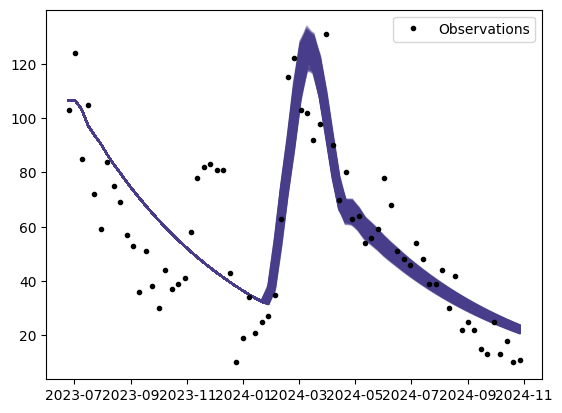

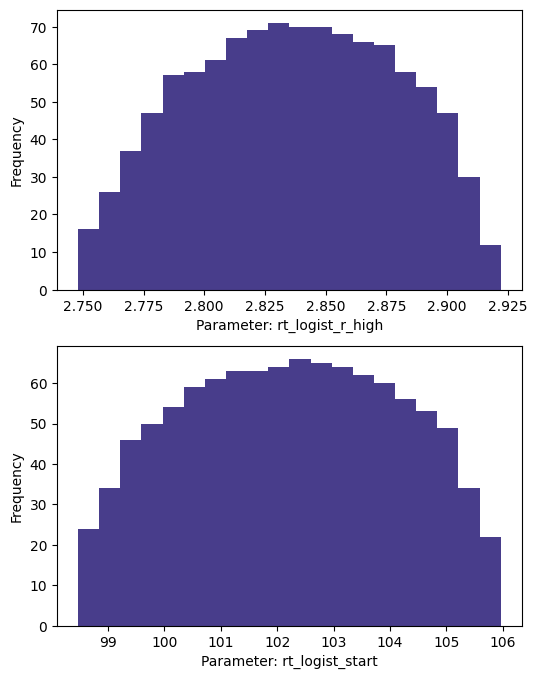

Average over selected parameter distributions: 
rt_logist_r_high      2.836574
rt_logist_start     102.233186
dtype: float64


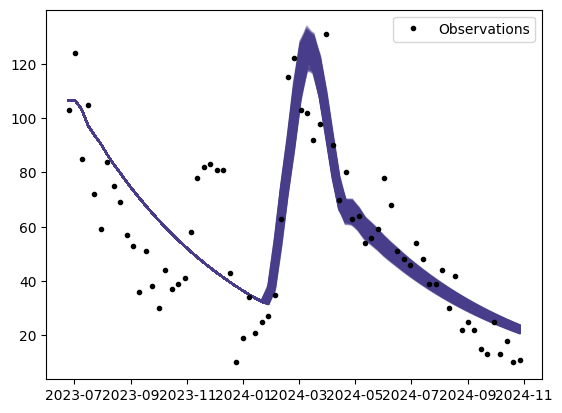

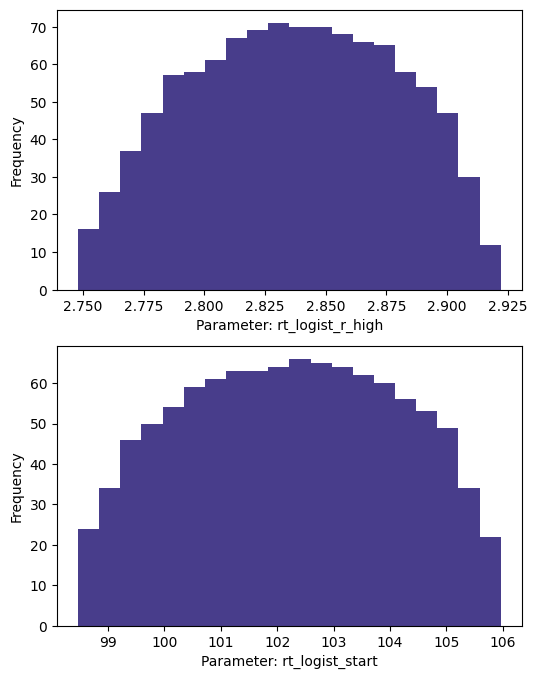

In [3]:
# --- Summary WIS statistics
# wis_sr = pd.Series(
#     results.scoring.wis_array.sum(axis=1),
# )
wis_sr = results.scoring.summary["wis"]
wis_sr.index.name = "i_simulation"
wis_sr.name = "total_wis"
# wis_df.columns =

# ----
# Test methods to select best simulations
# ======================================

# --- Simple n-best
# # -()- By number
# _n = min(200, wis_sr.shape[0])

# -()- By fraction of number of simulations
_nsim = wis_sr.shape[0]
_frac = 0.001
_n = np.ceil(_frac * _nsim).astype(int)

selected_wis_sr = wis_sr.nsmallest(_n)

best_median_case_trajectories_df = results.case_beam_df.xs(0.5, level="quantile").loc[selected_wis_sr.index]

# -()- Optional: Random sample to reduce plot load
nsample = 500
df: pd.DataFrame = best_median_case_trajectories_df
df = df.sample(nsample, replace=True, random_state=42)
best_median_case_trajectories_df = df


# Visualize results
# ====================
with plt.rc_context():
    fig, ax = plt.subplots()

    # Simulation medians
    df = best_median_case_trajectories_df
    ax.plot(df.T, color="darkslateblue", alpha=0.1)

    # Observations
    sr = observations_sr.loc[df.columns]
    ax.plot(sr, "o", ms=3, color="k", label="Observations")

    ax.legend()

    display(fig)

# Histogram of parameters
# ---------

sampled_param_names = list(config.sampling.param_ranges.keys())
best_sampled_params_df = params_df.loc[selected_wis_sr.index, sampled_param_names]

with plt.rc_context():
    fig, axes = plt.subplots(nrows=len(sampled_param_names), figsize=(6, 4 * len(sampled_param_names)))
    for i_param, param_name in enumerate(sampled_param_names):
        """"""
        ax: plt.Axes = axes[i_param]
        sr = best_sampled_params_df[param_name]
        ax.hist(sr, bins=20, color="darkslateblue")
        ax.set_xlabel(f"Parameter: {param_name}")
        ax.set_ylabel("Frequency")

    display(fig)

print(f"Average over selected parameter distributions: \n{best_sampled_params_df.mean(axis=0)}")


In [ ]:
# Colinearity plots (pairwise)
# ===============

with plt.rc_context():
    n_params = len(sampled_param_names)
    fig, axes = plt.subplots(
        nrows=n_params, ncols=n_params,
        figsize=(3 * n_params, 3 * n_params),
        squeeze=False,
    )

    for i, param_i in enumerate(sampled_param_names):
        for j, param_j in enumerate(sampled_param_names):
            ax: plt.Axes = axes[i, j]

            if i == j:
                # Diagonal: histogram
                ax.hist(best_sampled_params_df[param_i], bins=20, color="darkslateblue")
            else:
                # Off-diagonal: scatter
                ax.scatter(
                    best_sampled_params_df[param_j],
                    best_sampled_params_df[param_i],
                    s=2, alpha=0.3, color="darkslateblue", rasterized=True,
                )

            # Axis labels only on the outer edges
            if i == n_params - 1:
                ax.set_xlabel(param_j, fontsize=9)
            if j == 0:
                ax.set_ylabel(param_i, fontsize=9)

    fig.suptitle("Parameter collinearity check (best simulations)", y=1.01)
    plt.tight_layout()
    display(fig)

print(f"Average over selected parameter distributions: \n{best_sampled_params_df.mean(axis=0)}")

In [ ]:
# Recreating RT curves of selected trajectories
# =================
# OBS: This cell is complex because it reproduces how RT is generated inside the simulator. If we extract that as a method, this could be simplified.

# Rebuild the full params df but only with the best sampled parameters
_config = deepcopy(config)
_n = best_sampled_params_df.shape[0]
_config.sampling.method = "given"
_params_df = build_calibration_params_df(_n, _config.sampling, given_params=best_sampled_params_df)
t_start = float((_config.temporal.sim_start - _config.temporal.zero_date).days) - simulator._gt_max_steps * _config.temporal.step_dt


rt_array = simulator.rt_model.generate(
    params_df=_params_df,
    num_time_steps=_config.num_time_steps,
    step_dt=_config.temporal.step_dt,
    t_start=t_start,
)

# Shift time to assign dates
_cols = _config.temporal.zero_date + pd.Timedelta(t_start, unit="D") + pd.to_timedelta(np.arange(rt_array.shape[1]) * _config.temporal.step_dt, unit="D")
rt_df = pd.DataFrame(
    rt_array,
    index=best_sampled_params_df.index,
    columns=_cols,
)

# -()- Optional: Random sample to reduce plot load
nsample = 500
df: pd.DataFrame = rt_df
df = df.sample(nsample, replace=True, random_state=42)
rt_df = df

# Summarize and visualize
# =======================


with plt.rc_context():
    fig, ax = plt.subplots()

    # Simulation medians
    df = rt_df
    ax.plot(df.T, color="darkslateblue", alpha=0.1)
    ax.plot(df.columns, np.ones(df.shape[1]), "k--")
    ax.set_ylabel("Reproduction number (RT)")

    display(fig)


In [ ]:
from scipy.stats import pearsonr

pearsonr(
    best_sampled_params_df["rt_logist_start"],
    best_sampled_params_df["rt_logist_r_high"],
)

## Exercise - Bayesian, likelihood, priors, etc

In [ ]:
free_param_names = list(config.sampling.param_ranges.keys())

# Merge parameters and their scores
df = pd.merge(
    params_df, results.scoring.summary,
    left_index=True, right_index=True,
)

# Optional: Ressample to reduce load
df = df.sample(n=15000, replace=True, random_state=42)

fig, ax = plt.subplots()


# Plot samples as is
import matplotlib.tri as tri
triangulation = tri.Triangulation(
    df[free_param_names[0]],
    df[free_param_names[1]],
)
plot = ax.tripcolor(
    triangulation, -df["nb_loglikelihood"],
    vmin=-df["nb_loglikelihood"].quantile(0.50), vmax=-df["nb_loglikelihood"].max()
)
ax.set_xlabel(free_param_names[0])
ax.set_ylabel(free_param_names[1])
fig.colorbar(plot)

fig

In [ ]:
# Maximum likelihood run
# ======================

df = results.scoring.summary

print("Maximum likelihood simulation")
i_simulation_maxl = df["nb_loglikelihood"].idxmax()
params_df.loc[i_simulation_maxl]

In [ ]:
from scipy.stats import gaussian_kde

# IMPOSING PRIORS AFTER SIMULATIONS WERE RUN
## =================

# Let's see if we can gain identifiability just by post-weighting parameter samples with some priors.
df = pd.merge(
    params_df, results.scoring.summary,
    left_index=True, right_index=True,
)
sampled_param_names = list(config.sampling.param_ranges.keys())

# # --- Let's exponentiate the loglikelihood, displaced by the maximum achieved
# df["rel_loglikelihood"] = df["nb_loglikelihood"] - df["nb_loglikelihood"].max()  # Displace by max
# df.loc[df["rel_loglikelihood"] <= np.log(1E-250), "rel_loglikelihood"] = -np.inf  # Set to zero likelihood less than 1000 the max
# df["rel_likelihood"] = np.exp(df["rel_loglikelihood"])
# # hhmmmmmmm.... the loglikelihood is WAY too sensitive. When exponentiated, the best simulation is way above the others.

# --- Exponentiate likelihood with "Tempered posteriors" - Divide loglikelihood by a "temperature" to reduce sensitivity. This is equivalent to raising the likelihood to the power of 1/temperature, which flattens the distribution.
loglikelihood_temperature = 10**(0.0)
df["temp_loglikelihood"] = df["nb_loglikelihood"] / loglikelihood_temperature
df["rel_temp_loglikelihood"] = df["temp_loglikelihood"] - df["temp_loglikelihood"].max()  # Displace by max
# df.loc[df["rel_temp_loglikelihood"] <= np.log(1E-3), "rel_temp_loglikelihood"] = -np.inf  # Set to zero likelihood less than 1000 the max
df["temp_likelihood"] = np.exp(df["rel_temp_loglikelihood"])


# --- Define a prior over potential parameters
def _gauss(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def my_prior_01(_df: pd.DataFrame):
    """"""
    _p = pd.Series(1.0, index=_df.index)

    # if "notif_relative_scale" in _df.columns:
    #     _p *= _gauss(_df["notif_relative_scale"], mu=5.0, sigma=3.0)
    # #
    # if "rt_logist_w_center" in _df.columns:
    #     _p *= _gauss(_df["rt_logist_w_center"], mu=8.0, sigma=0.2)
    #
    # if "rt_logist_dt_center" in _df.columns:
    #
    #     _p *= _gauss(_df["rt_logist_dt_center"], mu=60., sigma=10.0)
    #
    #     # Enforce that dt_end > dt_center
    #     if "rt_logist_dt_end" in _df.columns:
    #         _p[_df["rt_logist_dt_end"] <= _df["rt_logist_dt_center"]] = 0.0

    return _p


df["prior"] = my_prior_01(df)
df["rel_posterior"] = df["temp_likelihood"] * df["prior"]  # Not normalized
# Zero-out small posteriors
df.loc[df["rel_posterior"] <= 1E-3 * df["rel_posterior"].max(), "rel_posterior"] = 0.

bayesian_df = df

print((df["rel_posterior"] > 0).sum())


# Univariate marginal posteriors
# ======
with plt.rc_context():
    fig, axes = plt.subplots(nrows=len(sampled_param_names), figsize=(6, 4 * len(sampled_param_names)))
    for i_param, param_name in enumerate(sampled_param_names):
        """"""
        ax: plt.Axes = axes[i_param]
        sr = bayesian_df[param_name]
        weights = bayesian_df["rel_posterior"]
        ax.hist(sr, weights=weights, bins=100, color="darkslateblue")
        # ax.hist(sr, weights=weights, color="darkslateblue")
        ax.set_xlabel(f"{param_name}")
        ax.set_ylabel("Weighted frequency")

    display(fig)

In [ ]:
# 2-Variable dispersion plots Marginal of each parameter
# =========
# NOTE: This plot takes a little while to render, due to the KDE calculations. Control the sample n to increase/decrease load.

# --- Sub-sample the dataframe for plotting (to reduce plot load)
bayes_small_df: pd.DataFrame = bayesian_df.sample(n=5000, replace=True, random_state=42)

with plt.rc_context():
    n_params = len(sampled_param_names)
    fig, axes = plt.subplots(
        nrows=n_params, ncols=n_params,
        figsize=(3 * n_params, 3 * n_params),
        squeeze=False,
    )

    for i, param_i in enumerate(sampled_param_names):
        for j, param_j in enumerate(sampled_param_names):
            print(f"\tPlotting {i=} vs {j=}...")
            ax: plt.Axes = axes[i, j]


            if i == j:
                # Diagonal: histogram
                df = bayesian_df
                ax.hist(df[param_i], weights=df["rel_posterior"], bins=20, color="darkslateblue")
            else:

                # # Off-diagonal: KDE contour
                df = bayes_small_df
                # df = bayesian_df
                x, y = df[param_j], df[param_i]
                values = np.vstack([x, y])
                kde = gaussian_kde(values, weights=df["rel_posterior"])
                # Resampling
                xi = np.linspace(x.min(), x.max(), 200)
                yi = np.linspace(y.min(), y.max(), 200)
                X, Y = np.meshgrid(xi, yi)
                Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

                ax.contourf(X, Y, Z, levels=30)

            ax.set_xlabel(param_j, fontsize=9)
            ax.set_ylabel("p" if i == j else param_i, fontsize=9)

            # # Axis labels only on the outer edges
            # if i == n_params - 1:
            #     ax.set_xlabel(param_j, fontsize=9)
            # if j == 0:
            #     ax.set_ylabel(param_i, fontsize=9)


    fig.suptitle("Parameter collinearity check", y=1.01)
    plt.tight_layout()
    display(fig)


In [ ]:
df = bayesian_df

# weights = df["rel_posterior"] / df["rel_posterior"].sum()  # Normalize to sum to 1
# 1. / (weights ** 2).sum()

In [ ]:
# TEST: Inverse CDF of the normal
# ===========

from scipy.stats import norm

rng = np.random.default_rng(42)
u_sample = rng.uniform(size=int(1E6))

norm_sample = norm.ppf(u_sample, loc=0, scale=1)

fig, ax = plt.subplots()
pd.Series(norm_sample).hist(ax=ax)

fig
# u_sample

In [11]:
import json
import yaml
import io

# json.loads("[1, 2, 3]")

# yaml.load(io.StringIO("{aba: baba}"), yaml.SafeLoader)
yaml.load(io.StringIO("[123, "), yaml.SafeLoader)


ParserError: while parsing a flow node
expected the node content, but found '<stream end>'
  in "<file>", line 1, column 7